

---

## The **Machine Learning** phase begins!

In [ ]:
import pandas as pd
import requests

gold_ml_features = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"

df = pd.read_csv(gold_ml_features)

# Inpsecting
print(df.info(), '\n')
display(df.head(7))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerID                  300 non-null    int64  
 1   customer_value_quintile     300 non-null    int64  
 2   total_transactions          300 non-null    int64  
 3   lifetime_spend              300 non-null    int64  
 4   avg_transaction_value       300 non-null    float64
 5   avg_unit_price              300 non-null    int64  
 6   total_items                 300 non-null    int64  
 7   avg_items_per_transaction   300 non-null    float64
 8   unique_products             300 non-null    int64  
 9   unique_franchises           300 non-null    int64  
 10  payment_method_diversity    300 non-null    int64  
 11  first_purchase              300 non-null    object 
 12  last_purchase               300 non-null    object 
 13  recency_days                300 non

,customerID,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,...,customer_lifetime_days,avg_days_between_purchases,active_days,active_months,revenue_per_order,avg_basket_size,avg_monthly_spend,multi_franchise_customer,high_value_customer,churn_label
0,2000000,3,9,201,22.33,3,67,7.44,4,8,...,14,1.75,7,1,22.33,7.44,201,1,0,1
1,2000001,4,8,153,19.13,3,51,6.38,4,7,...,9,1.29,4,1,19.13,6.38,153,1,0,1
2,2000002,1,17,327,19.24,3,109,6.41,5,15,...,15,0.94,12,1,19.24,6.41,327,1,1,1
3,2000003,3,13,216,16.62,3,72,5.54,5,10,...,13,1.08,10,1,16.62,5.54,216,1,0,1
4,2000004,1,17,363,21.35,3,121,7.12,6,16,...,16,1.00,11,1,21.35,7.12,363,1,1,1
5,2000005,1,21,330,15.71,3,110,5.24,6,17,...,14,0.70,11,1,15.71,5.24,330,1,1,1
6,2000006,1,18,480,26.67,3,160,8.89,5,15,...,16,0.94,10,1,26.67,8.89,480,1,1,1


## Production-Grade Data Engineering & Cleaning

To make the data loading and cleaning process more robust, reusable, and maintainable for repetitive company use, I will define my Data Ingestion/Data Engineering steps into dedicated functions.

This approach promotes modularity, readability, and easier testing.

In [ ]:
def load_gold_ml_dataset():
  url = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"
  df = pd.read_csv(url)
  df = clean_customer_churn_data(df)
  return df.sample(8)

In [ ]:
def load_customer_churn_data(url: str) -> pd.DataFrame:
    """
    Loads customer churn data from a given URL into a pandas DataFrame.

    Args:
        url (str): The URL of the CSV file containing the data.

    Returns:
        pd.DataFrame: The loaded customer churn data.
    """
    try:
        df = pd.read_csv(url)
        print(f"Successfully loaded data from {url}")
        print(df.info(), '\n')
        return df
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from URL: {e}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        return pd.DataFrame()

In [ ]:
def clean_customer_churn_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Performs standard cleaning and organization on the customer churn DataFrame.
    This includes converting specific columns to 'str' type, filling NaN values with 0,
    and dropping duplicate rows.

    Args:
        df (pd.DataFrame): The input DataFrame requiring cleaning.

    Returns:
        pd.DataFrame: The cleaned DataFrame.
    """

    if df.empty:
        print("Input DataFrame is empty, returning as is.")
        return df

    str_cols = ['customerID', 'customer_value_quintile', 'multi_franchise_customer',
                'high_value_customer', 'churn_label']
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].astype('str')
        else:
            print(f"Warning: Column '{col}' not found in DataFrame for type conversion.")

    df.fillna(0, inplace = True)
    print("NaN values filled with 0.")

    initial_rows = len(df)
    df.drop_duplicates(inplace = True)
    if len(df) < initial_rows:
        print(f"Dropped {initial_rows - len(df)} duplicate rows.")
    else:
        print("No duplicate rows found.")

    return df

### Principal Component Analysis (PCA)

Before applying K-Means, we'll perform Principal Component Analysis (PCA) on the selected features to reduce dimensionality and decorrelate them. This can sometimes improve clustering performance and interpretability.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np

# Select features for PCA. Original intended features ('expected revenue', 'standardized_log_order')
# were not found. Substituting with 'lifetime_spend' and 'total_transactions' from the available data.
features_for_pca = df[['total_transactions', 'lifetime_spend', 'avg_transaction_value',
                       'avg_unit_price', 'total_items', 'avg_items_per_transaction',
                       'unique_products', 'active_days', 'avg_basket_size', 'customer_lifetime_days']]

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_pca)

# Display the first few rows of the scaled features
print("Scaled Features:")
display(pd.DataFrame(scaled_features, columns=features_for_pca.columns))

Scaled Features:


,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,active_days,avg_basket_size,customer_lifetime_days
0,-0.654769,-0.221976,0.402621,0.0,-0.221976,0.400859,-1.184726,-0.560459,0.400859,0.233168
1,-0.965086,-0.739957,-0.124801,0.0,-0.739957,-0.123226,-1.184726,-2.066168,-0.123226,-2.283033
2,1.827768,1.137722,-0.106671,0.0,1.137722,-0.108393,-0.059986,1.949057,-0.108393,0.736408
3,0.586499,-0.060107,-0.538498,0.0,-0.060107,-0.538538,-0.059986,0.945251,-0.538538,-0.270072
4,1.827768,1.526208,0.241098,0.0,1.526208,0.242645,1.064754,1.447154,0.242645,1.239648
...,...,...,...,...,...,...,...,...,...,...
295,0.896817,0.813985,0.218023,0.0,0.813985,0.217924,-0.059986,-0.058555,0.217924,-0.773313
296,1.207134,0.554994,-0.278083,0.0,0.554994,-0.276496,1.064754,1.447154,-0.276496,0.233168
297,-0.344452,0.231257,0.727315,0.0,0.231257,0.727176,1.064754,-0.058555,0.727176,-0.270072
298,0.276182,0.813985,0.801483,0.0,0.813985,0.801339,-1.184726,0.443348,0.801339,1.239648


In [ ]:
# Apply PCA

pca = PCA(n_components = 3) # No. of Components that will Cover 99% of the Variance
pca_components = pca.fit_transform(scaled_features)

# Determine the actual number of components after fitting PCA
num_components = pca.n_components_
pca_column_names = [f'PC{i+1}' for i in range(num_components)]

# Create a DataFrame for the Principal Components
# Use the dynamically generated column names to match the pca_components shape
df_pca = pd.DataFrame(data = pca_components, columns = pca_column_names)

# Add the PCA components to the original DataFrame for later use
# Only add PC1 and PC2, as suggested by downstream usage (e.g., plotting)
# Ensure these columns exist before attempting to assign
if 'PC1' in df_pca.columns:
    df['PC1'] = df_pca['PC1']
else:
    df['PC1'] = np.nan # Assign NaN if PC1 doesn't exist

if 'PC2' in df_pca.columns:
    df['PC2'] = df_pca['PC2']
else:
    df['PC2'] = np.nan # Assign NaN if PC2 doesn't exist


# Interpreting the PCA (Loadings and Explained Variance)
features = features_for_pca.columns # Define 'features' from the selected columns

# The loadings should also reflect the actual number of components
loadings = pd.DataFrame(
    pca.components_.T,
    columns = pca_column_names, # Use dynamically generated column names for loadings
    index = features
)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance": explained_var,
    "Cumulative Variance": np.cumsum(explained_var)
})

# Combine PCA results into a single DataFrame
combined_pca_df = pca_summary.set_index('PC').join(loadings.T)

print("\nCombined PCA Analysis DataFrame:")
display(combined_pca_df) # Covers 90% of Variance = Good enough!

# print("\nPrincipal Components (first 5 rows):")
# display(df_pca)


Combined PCA Analysis DataFrame:


,Explained Variance,Cumulative Variance,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,active_days,avg_basket_size,customer_lifetime_days
PC,,,,,,,,,,,,
PC1,0.539213,0.539213,0.267175,0.442148,0.369102,-0.000000e+00,0.442148,0.369083,0.196688,0.274468,0.369083,0.122183
PC2,0.275591,0.814803,0.467782,0.068575,-0.364147,-0.000000e+00,0.068575,-0.364186,0.327409,0.432815,-0.364186,0.281751
PC3,0.095540,0.910343,-0.167562,-0.065137,0.051203,-2.220446e-16,-0.065137,0.051116,-0.420383,0.076502,0.051116,0.879213




---

## Customer Segmentation: PCA + K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Identifying the Optimum Number of Clusters - Elbow Plot & Silhouette Score, both

def optimize_k_means(data, max_k):
  means = []
  inertias = []
  silhouette_scores = []

  # Elbow Plot calculation loop
  for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 10, n_init=10)
    kmeans.fit(data)
    means.append(k)
    inertias.append(kmeans.inertia_)

  # Silhouette Score calculation loop (Silhouette score is not defined for k=1)
  for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 10, n_init=10)
    cluster_labels = kmeans.fit_predict(data)
    score = silhouette_score(data, cluster_labels)
    silhouette_scores.append(score)

  # Generating the Elbow Plot (moved outside loop)
  plt.style.use('default')
  plt.figure(figsize = (10, 5))
  plt.plot(means, inertias, 'o--')
  plt.xlabel('Number of Clusters (k)')
  plt.xticks(means)
  plt.ylabel('Inertia')
  plt.title('Elbow Plot for PCA Components')
  plt.grid(True)
  plt.show()

  # Plotting the Silhouette Score (moved outside loop)
  plt.figure(figsize = (10, 5))
  plt.plot(range(2, max_k + 1), silhouette_scores, marker = 'o')
  plt.title('Silhouette Score for K-Means Clustering on PCA Components')
  plt.xlabel('Number of Clusters (k)')
  plt.ylabel('Silhouette Score')
  plt.grid(True)
  plt.show()

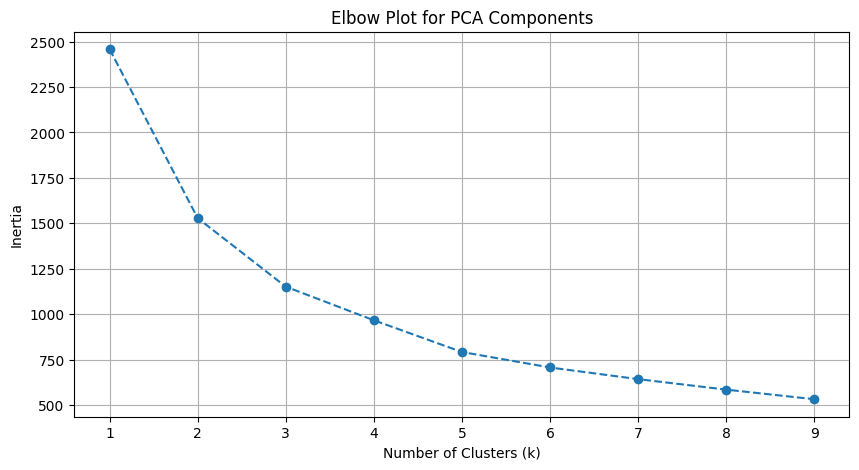

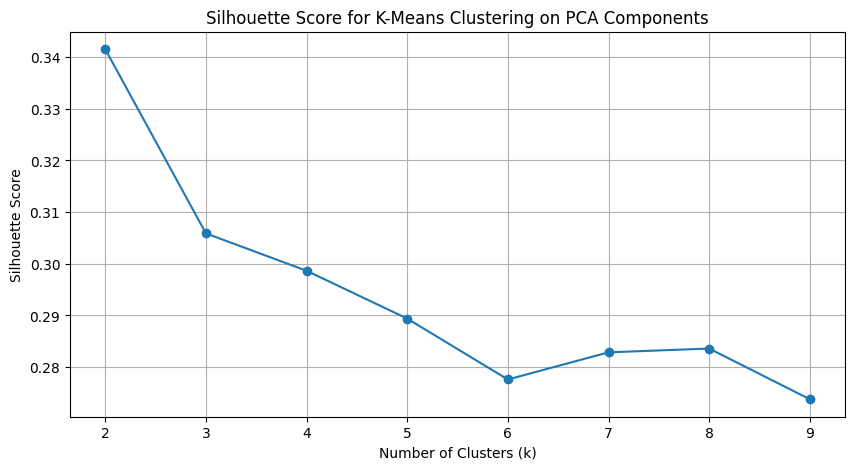

In [ ]:
optimize_k_means(df_pca, 9)

In [ ]:
# 2 Clusters appear Optimal
# Verdict (Based on Elbow Plot & Silhouette Score): Let's assume an optimal K is determined.

# Applying K-Means Clustering on PCA components
kmeans = KMeans(n_clusters = 2, random_state=10, n_init = 10) # Using "n_init" for modern KMeans
kmeans.fit(df_pca)

# Assign clusters back to the original Dataset
df['kmeans_cluster_pca'] = kmeans.labels_ + 1 # +1 to start cluster numbering from 1

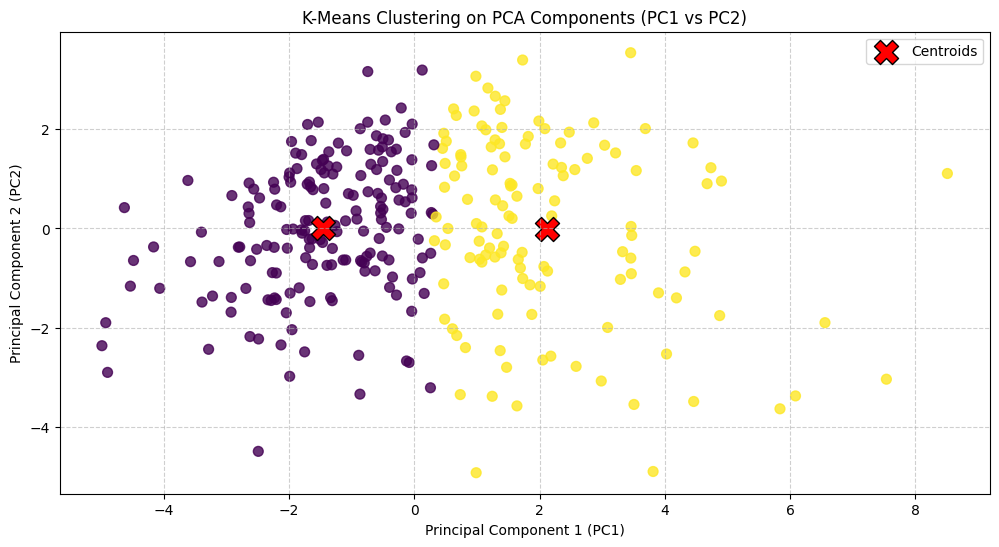

In [ ]:
import matplotlib.pyplot as plt

# Plotting the Results using PCA components

centroids = kmeans.cluster_centers_ # Use the centroids from the K-Means applied to PCA data

plt.style.use('default')
plt.figure(figsize = (12, 6))
plt.scatter(x = df['PC1'], y = df['PC2'], c = df['kmeans_cluster_pca'], cmap='viridis', s=50, alpha=0.8)
plt.scatter(x = centroids[:, 0], y = centroids[:, 1], s = 300, c = 'red', marker = 'X', label = 'Centroids', edgecolors='black') # Plotting the Centroids
plt.title('K-Means Clustering on PCA Components (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Comparing Results from Multiple Clusters using PCA components

for k in range(1, 6): # 1 to 5 Clusters
  kmeans_temp = KMeans(n_clusters = k, random_state=10, n_init=10)
  kmeans_temp.fit(df_pca)
  df[f"K-Means_{k}_PCA"] = kmeans_temp.labels_

df.sample(7)

,customerID,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,...,high_value_customer,churn_label,PC1,PC2,kmeans_cluster_pca,K-Means_1_PCA,K-Means_2_PCA,K-Means_3_PCA,K-Means_4_PCA,K-Means_5_PCA
16,2000016,3,13,207,15.92,3,69,5.31,5,12,...,0,1,-0.505293,1.345710,1,0,0,1,2,4
208,2000208,2,14,246,17.57,3,82,5.86,5,14,...,1,1,0.450132,1.610514,2,0,1,1,2,0
90,2000090,2,15,252,16.80,3,84,5.60,6,13,...,1,1,0.669786,2.272651,2,0,1,1,2,0
23,2000023,1,14,390,27.86,3,130,9.29,5,13,...,1,1,3.456144,-0.596322,2,0,1,2,0,1
95,2000095,1,11,354,32.18,3,118,10.73,5,11,...,1,1,3.898186,-1.295787,2,0,1,2,0,1
155,2000155,2,13,291,22.38,3,97,7.46,6,11,...,1,1,1.510718,0.250938,2,0,1,1,2,0
91,2000091,2,15,246,16.40,3,82,5.47,4,15,...,1,1,-0.039452,1.380862,1,0,0,1,2,4


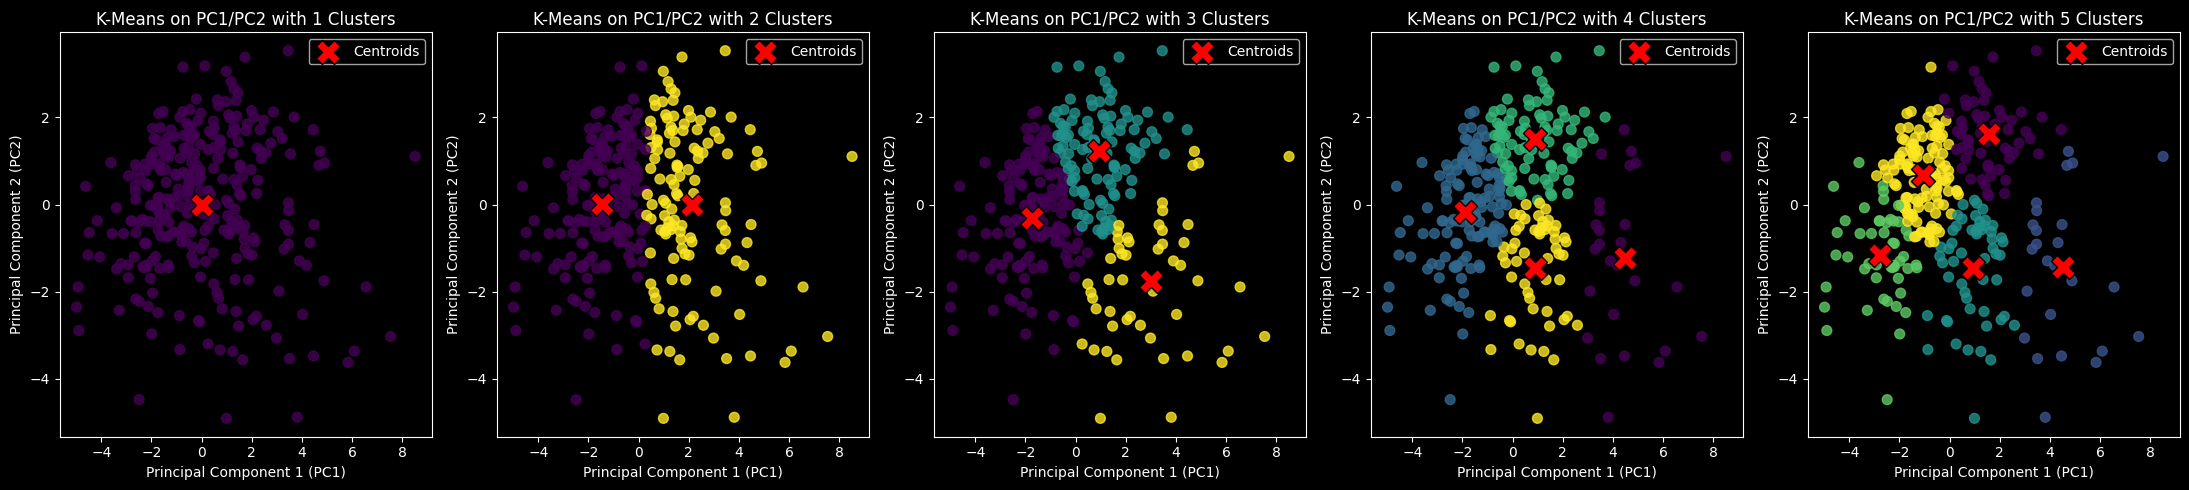

In [ ]:
plt.style.use('dark_background')

fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (22, 5))

for i, ax in enumerate(fig.axes, start = 1):
  kmeans_temp = KMeans(n_clusters = i, random_state = 10, n_init=10)
  kmeans_temp.fit(df_pca)
  centroids = kmeans_temp.cluster_centers_

  ax.scatter(x = df['PC1'], y = df['PC2'], c = df[f"K-Means_{i}_PCA"], cmap='viridis', s=50, alpha=0.8)
  ax.scatter(x = centroids[:, 0], y = centroids[:, 1], s = 300, c = 'red', marker = 'X', label = 'Centroids', edgecolors='black') # Plotting the Centroids too
  ax.set_title(f"K-Means on PC1/PC2 with {i} Clusters")
  ax.set_xlabel("Principal Component 1 (PC1)")
  ax.set_ylabel("Principal Component 2 (PC2)")
  ax.legend()

plt.tight_layout()
plt.show()

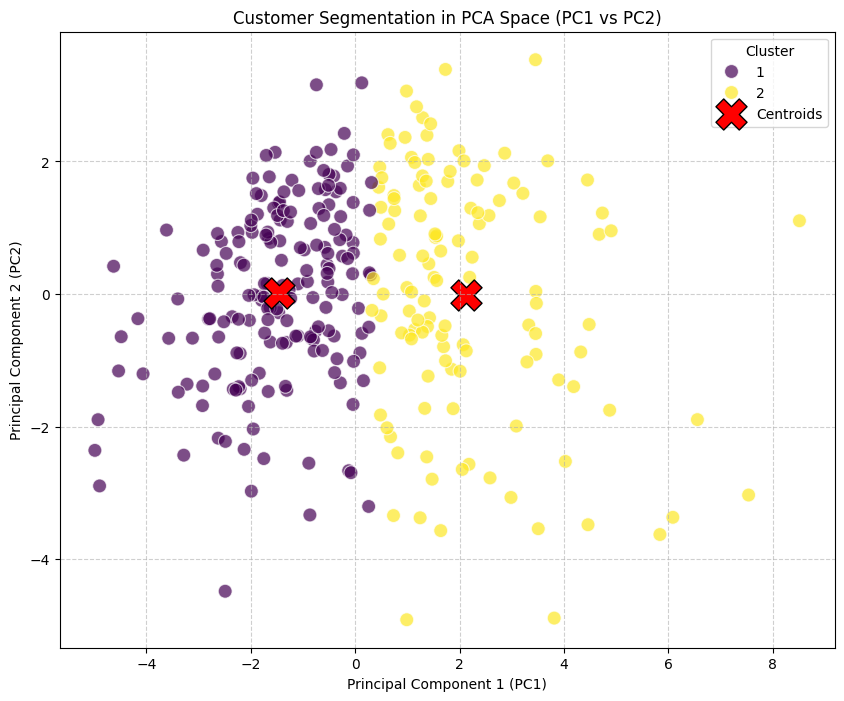

In [ ]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Replacing the previous 3D plot with a 2D scatter plot as we have 2 principal components.

plt.style.use('default')
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='kmeans_cluster_pca', # Color by the identified cluster
    palette='viridis', # A good palette for distinguishing clusters
    s=100, # Size of points
    alpha=0.7,
    legend='full' # Show the full legend
)

# Plot centroids on top
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=500, # Large size for centroids
    color='red',
    label='Centroids',
    edgecolors='black'
)

plt.title('Customer Segmentation in PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()